In [64]:
# ---------------------------
# 0. Bibliotecas
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------
# 1. Ler CSVs (ROBUSTO)
# ---------------------------
def read_summary(path):
    df = pd.read_csv(path, sep=None, engine="python")
    # se veio tudo em uma coluna, força split
    if len(df.columns) == 1 and ',' in df.columns[0]:
        df = pd.read_csv(path, sep=',', engine="python")
    return df

knn_df = read_summary('KNN.csv')
mlp_df = read_summary('MLP.csv')
rf_df  = read_summary('RF.csv')

# ---------------------------
# 2. Limpar colunas
# ---------------------------
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
    return df

knn_df = clean_columns(knn_df)
mlp_df = clean_columns(mlp_df)
rf_df  = clean_columns(rf_df)

# ---------------------------
# 3. Detectar colunas automaticamente
# ---------------------------
def get_clf_cols(df, method_prefix=''):
    
    if method_prefix == '':
        mean_cols = [c for c in df.columns if c.startswith('clf_') and c.endswith('_mean')]
        std_cols  = [c for c in df.columns if c.startswith('clf_') and c.endswith('_std')]
    else:
        mean_cols = [c for c in df.columns if c.startswith(f'clf_{method_prefix}') and c.endswith('_mean')]
        std_cols  = [c for c in df.columns if c.startswith(f'clf_{method_prefix}') and c.endswith('_std')]

    id_vars = [c for c in ['dataset','missing_frac'] if c in df.columns]

    if len(id_vars) < 2:
        raise ValueError(
            f"Não encontrou as colunas 'dataset' e 'missing_frac'. Colunas disponíveis: {df.columns.tolist()}"
        )

    return id_vars, mean_cols, std_cols

knn_id, knn_mean_cols, knn_std_cols = get_clf_cols(knn_df)
mlp_id, mlp_mean_cols, mlp_std_cols = get_clf_cols(mlp_df,'mlp')
rf_id, rf_mean_cols, rf_std_cols    = get_clf_cols(rf_df,'rf')

# ---------------------------
# 4. Função para criar long format
# ---------------------------
def long_format(df, id_vars, mean_cols, std_cols, method_name):

    long = pd.melt(
        df,
        id_vars=id_vars,
        value_vars=mean_cols,
        var_name='variant',
        value_name='clf_mean'
    )

    std_long = pd.melt(
        df,
        id_vars=id_vars,
        value_vars=std_cols,
        var_name='variant_std',
        value_name='clf_std'
    )

    std_long['variant'] = std_long['variant_std'].str.replace('_std','')
    long['variant'] = long['variant'].str.replace('_mean','')

    long = long.merge(
        std_long[[*id_vars,'variant','clf_std']],
        on=[*id_vars,'variant'],
        how='left'
    )

    long['method'] = method_name

    return long

# ---------------------------
# 5. Criar long formats
# ---------------------------
knn_long = long_format(knn_df, knn_id, knn_mean_cols, knn_std_cols, 'KNN')
baseline = knn_long[knn_long['variant'] == 'clf_original']
baseline = baseline[['dataset','missing_frac','clf_mean']]
baseline = baseline.rename(columns={'clf_mean':'baseline_mean'})
knn_long = knn_long.merge(
    baseline,
    on=['dataset','missing_frac'],
    how='left'
)
knn_long['delta_clf'] = knn_long['clf_mean'] - knn_long['baseline_mean']



mlp_long = long_format(mlp_df, mlp_id, mlp_mean_cols, mlp_std_cols, 'MLP')
baseline = mlp_df[['dataset','missing_frac','clf_original_mean']].rename(columns={'clf_original_mean':'baseline_mean'})
mlp_long = mlp_long.merge(
    baseline,
    on=['dataset','missing_frac'],
    how='left'
)
mlp_long['delta_clf'] = mlp_long['clf_mean'] - mlp_long['baseline_mean']
mlp_long_plot = mlp_long[mlp_long['delta_clf'].notna()]





rf_long = long_format(rf_df, rf_id, rf_mean_cols, rf_std_cols, 'RF')
baseline = rf_df[['dataset','missing_frac','clf_original_mean']].rename(columns={'clf_original_mean':'baseline_mean'})
rf_long = rf_long.merge(
    baseline,
    on=['dataset','missing_frac'],
    how='left'
)
rf_long['delta_clf'] = rf_long['clf_mean'] - rf_long['baseline_mean']
rf_long_plot = rf_long[rf_long['delta_clf'].notna()]

# ---------------------------
# 6. NÃO criar gráficos de linhas
# ---------------------------
# Apenas manter os dados em long format e estatísticas
# plot_performance() NÃO será chamado

# ---------------------------
# 7. Estatísticas descritivas completas
# ---------------------------
all_long = pd.concat([knn_long, mlp_long, rf_long], ignore_index=True)
stats = all_long.groupby(['method','variant','dataset','missing_frac']).agg(
    clf_mean_avg=('clf_mean','mean'),
    clf_std_avg=('clf_std','mean')
)

# stats agora contém todas as estatísticas sem gerar gráfico

In [65]:
def plot_knn_bar(knn_long, variant_name):

    sub = knn_long[knn_long['variant'] == variant_name]

    datasets = sub['dataset'].unique()
    missing = sorted(sub['missing_frac'].unique())

    x = np.arange(len(missing))
    width = 0.8 / len(datasets)

    plt.figure(figsize=(12,6))

    for i, dataset in enumerate(datasets):

        sub2 = sub[sub['dataset'] == dataset].sort_values('missing_frac')

        plt.bar(
            x + i*width,
            sub2['delta_clf'],
            width,
            label=dataset
        )

    plt.xticks(x + width*(len(datasets)-1)/2, missing)
    plt.xlabel("Missing fraction")
    plt.ylabel("Δ Acurácia vs baseline")
    plt.title(f"KNN – Variante {variant_name}")
    plt.legend(title="Dataset", bbox_to_anchor=(1.05,1))
    plt.tight_layout()
    plt.show()

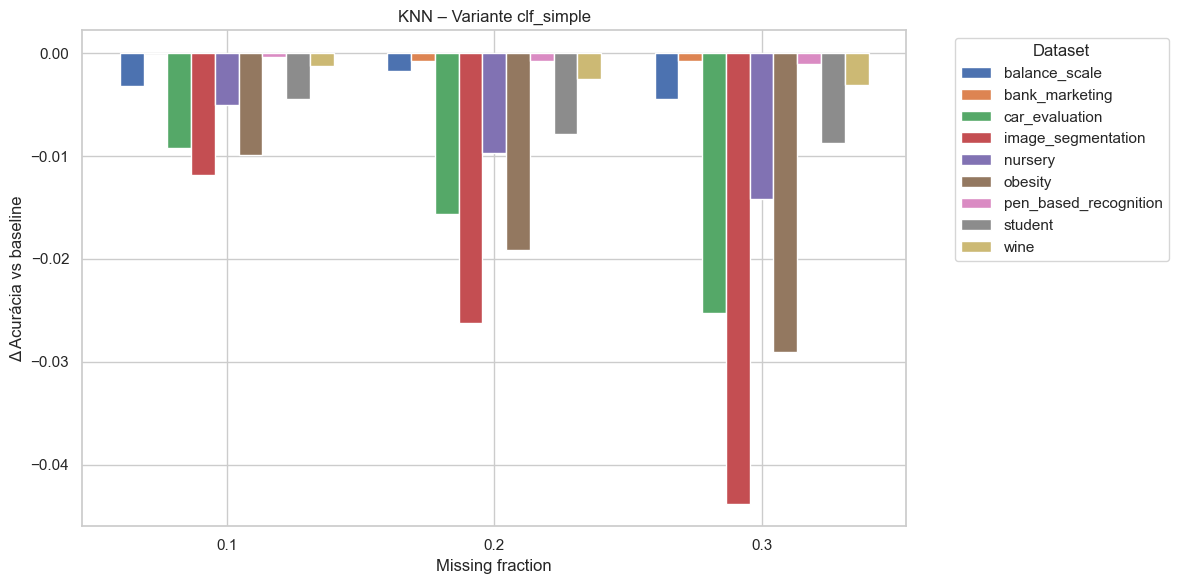

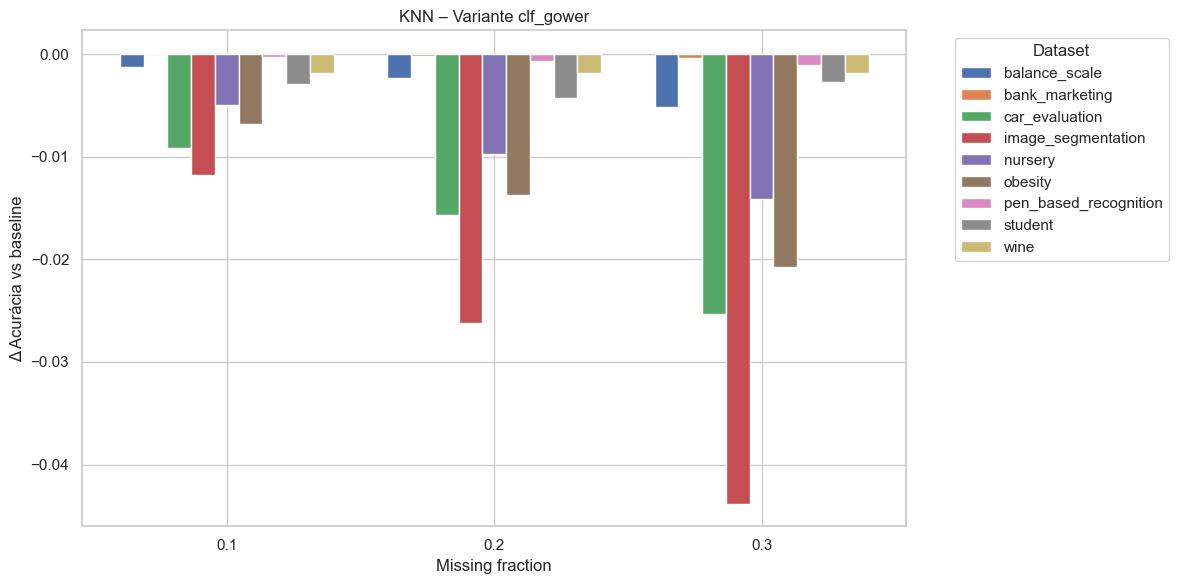

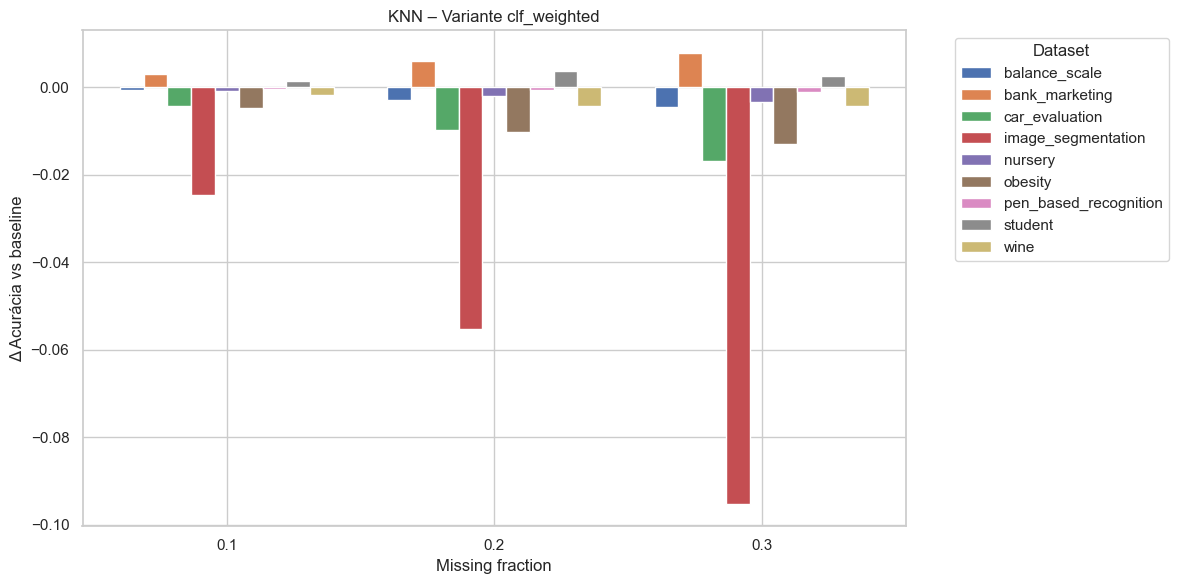

In [66]:
plot_knn_bar(knn_long, 'clf_simple')
plot_knn_bar(knn_long, 'clf_gower')
plot_knn_bar(knn_long, 'clf_weighted')


In [67]:
# =========================================================
# Tabela de Cardinalidade das Variáveis Alvo
# =========================================================

DATASETS = {    
    'wine': {
        'path': '../data/wine/wine.data',
        'columns': [
            'Class',
            'Alcohol', 'Malic', 'Ash', 'Alcalinity',
            'Magnesium', 'Phenols', 'Flavanoids',
            'Nonflav', 'Proanth', 'Color', 'Hue',
            'OD', 'Proline'
        ],
        'target': 'Class',
        'drop': []
    },
    'image_segmentation': {
        'path': '../data/image_segmentation/segmentation_full_clean.csv',
        'sep': ',',
        'header': 0,
        'columns': [
            'Class',
            'Region-centroid-col', 'Region-centroid-row',
            'Region-pixel-count', 'Short-line-density-5',
            'Short-line-density-2', 'Vedge-mean',
            'Vedge-sd', 'Hedge-mean', 'Hedge-sd',
            'Intensity-mean', 'Rawred-mean',
            'Rawblue-mean', 'Rawgreen-mean',
            'Exred-mean', 'Exblue-mean', 'Exgreen-mean',
            'Value-mean', 'Saturation-mean', 'Hue-mean'
        ],
        'target': 'Class',
        'drop': []
    },
    'pen_based_recognition': {
        'path': '../data/pen_based_recognition/pendigits_full.csv',
        'sep': ',',
        'header': 0,
        'columns': None,   
        'target': 'Class',
        'drop': []
},
    'student': {
        'path': '../data/student/student-por.csv', 
        'sep': ';',          # IMPORTANTE: essa base usa ';'
        'header': 0,         # primeira linha é cabeçalho
        'columns': None,     # já vem com nomes
        'target': 'G3',      # nota final
        'drop': []
    },
    'obesity': {
        'path': '../data/obesity/ObesityDataSet_raw_and_data_sinthetic.csv',
        'sep': ',',
        'header': 0,
        'columns': None,
        'target': 'NObeyesdad',
        'drop': []
    },
        'bank_marketing': {
        'path': '../data/bank/bank-full.csv',
        'sep': ';',
        'header': 0,
        'columns': None,         # usa os nomes do CSV
        'target': 'job',           # coluna alvo (yes/no)
        'drop': []
    },
    'balance_scale': {
        'path': '../data/balance_scale/balance-scale.data',
        'sep': ',',
        'header': None,     # NÃO há cabeçalho
        'columns': [
            'Class',
            'Left-Weight',
            'Left-Distance',
            'Right-Weight',
            'Right-Distance'
        ],
        'target': 'Class',
        'drop': []
    },
    'nursery': {
        'path': '../data/nursery/nursery.data',
        'sep': ',',
        'header': None,   # NÃO há cabeçalho
        'columns': [
            'Parents',
            'Has_nurs',
            'Form',
            'Children',
            'Housing',
            'Finance',
            'Social',
            'Health',
            'Class'
        ],
        'target': 'Class',
        'drop': []
},
    'car_evaluation': {
        'path': '../data/car_evaluation/car.data',
        'sep': ',',
        'header': None,   # não tem cabeçalho
        'columns': [
            'buying',
            'maint',
            'doors',
            'persons',
            'lug_boot',
            'safety',
            'class'
        ],
        'target': 'class',
        'drop': []
    }
}

def generate_target_cardinality_table(DATASETS):
    rows = []

    for name, cfg in DATASETS.items():

        # leitura igual à pipeline principal
        if cfg.get('columns') is not None:
            df = pd.read_csv(
                cfg['path'],
                header=None,
                names=cfg['columns'],
                sep=cfg.get('sep', ',')
            )
        else:
            df = pd.read_csv(
                cfg['path'],
                header=cfg.get('header', 0),
                sep=cfg.get('sep', ',')
            )

        if cfg.get('n_rows'):
            df = df.iloc[:cfg['n_rows']]

        if cfg['drop']:
            df = df.drop(columns=cfg['drop'])

        target = cfg['target']
        y = df[target]

        # mesmo filtro que você usa antes do stratify
        vc = y.value_counts()
        valid_classes = vc[vc >= 2].index
        y = y[y.isin(valid_classes)]

        cardinality = y.nunique()
        total_samples = len(y)

        dist = y.value_counts(normalize=True)

        rows.append({
            "Dataset": name,
            "Target": target,
            "Amostras": total_samples,
            "Cardinalidade": cardinality,
            "Maior Classe (%)": round(dist.max() * 100, 2),
            "Menor Classe (%)": round(dist.min() * 100, 2),
            "Prob. Acerto Aleatório (1/k)": round(1/cardinality, 4)
        })

    table = pd.DataFrame(rows).sort_values("Cardinalidade")
    return table


cardinality_table = generate_target_cardinality_table(DATASETS)

display("\n=== Tabela de Cardinalidade das Variáveis Alvo ===")
display(cardinality_table)

'\n=== Tabela de Cardinalidade das Variáveis Alvo ==='

,Dataset,Target,Amostras,Cardinalidade,Maior Classe (%),Menor Classe (%),Prob. Acerto Aleatório (1/k)
0,wine,Class,178,3,39.89,26.97,0.3333
6,balance_scale,Class,625,3,46.08,7.84,0.3333
8,car_evaluation,class,1728,4,70.02,3.76,0.2500
7,nursery,Class,12960,5,33.33,0.02,0.2000
4,obesity,NObeyesdad,2111,7,16.63,12.88,0.1429
1,image_segmentation,Class,2312,8,14.27,0.09,0.1250
2,pen_based_recognition,Class,10992,10,10.41,9.60,0.1000
5,bank_marketing,job,45211,12,21.53,0.64,0.0833
3,student,G3,647,15,16.07,0.31,0.0667


In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_performance_by_dataset_bars_grid_safe(df, title_prefix=""):

    # remover baseline (sempre delta = 0)
    df = df[~df['variant'].str.contains('original')]

    datasets = df['dataset'].unique()
    n = len(datasets)

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4), squeeze=False)
    axes = axes.flatten()

    for i, dataset in enumerate(datasets):

        ax = axes[i]

        sub = df[df['dataset']==dataset].copy()

        sub.sort_values(['missing_frac','variant'], inplace=True)

        sns.barplot(
            data=sub,
            x='missing_frac',
            y='delta_clf',
            hue='variant',
            palette='Set2',
            ax=ax
        )

        # linha baseline
        ax.axhline(0, color='black', linestyle='--')

        ax.set_title(f"{dataset}")
        ax.set_xlabel("Missing fraction")
        ax.set_ylabel("Δ Acurácia vs baseline")

        ax.legend_.remove()

    # remover eixos extras
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # legenda geral
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title="Variante", bbox_to_anchor=(1.02, 0.5), loc='center left')

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0,0,0.85,0.95])

    plt.show()

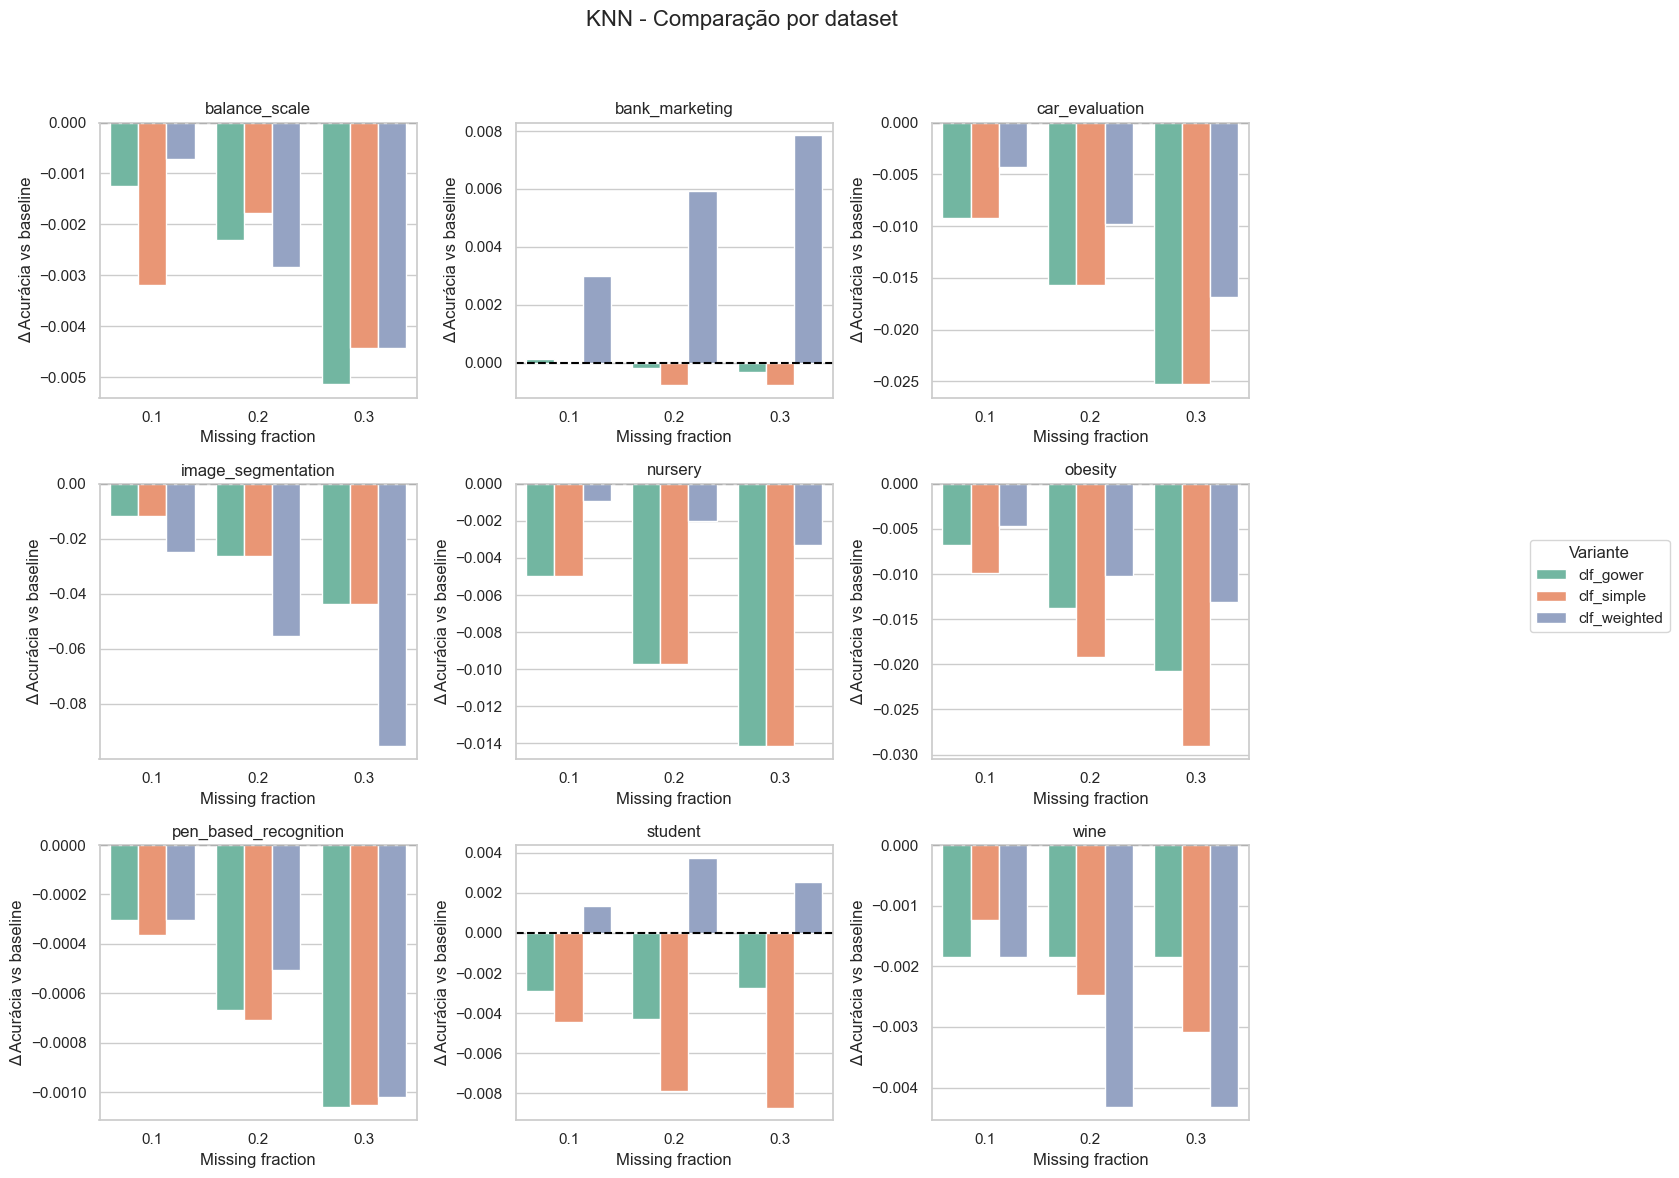

In [69]:
plot_performance_by_dataset_bars_grid_safe(knn_long, title_prefix="KNN - Comparação por dataset")

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_mlp_delta(df, title=""):
    df_plot = df[df['delta_clf'].notna()]

    if df_plot.empty:
        print("⚠️ DataFrame vazio! Verifique delta_clf")
        return

    plt.figure(figsize=(14,7))
    ax = sns.barplot(
        data=df_plot,
        x='missing_frac',
        y='delta_clf',
        hue='dataset',
        palette='Set2'
    )
    ax.axhline(0, color='black', linestyle='--')
    plt.title(title)
    plt.ylabel("Δ Acurácia vs clf_original_mean")
    plt.xlabel("Fração de missing")
    plt.tight_layout()
    plt.show()

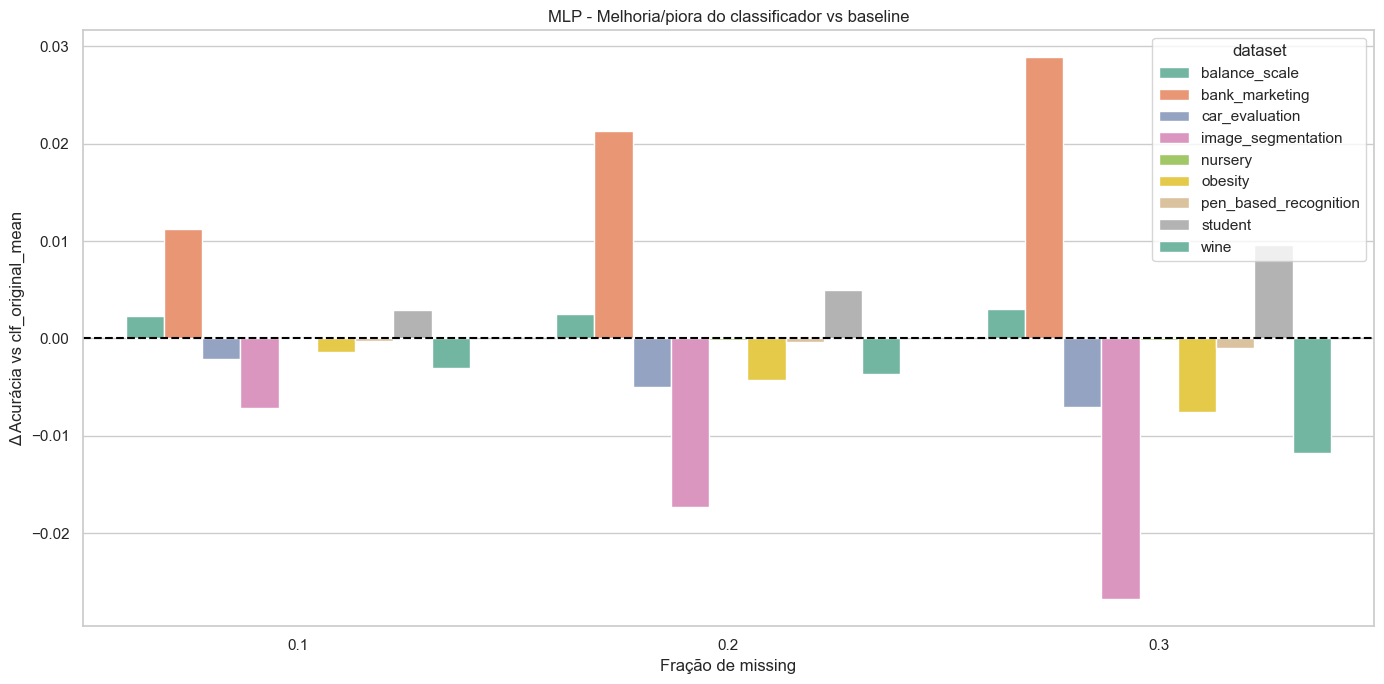

In [71]:
plot_mlp_delta(
    mlp_long,
    title="MLP - Melhoria/piora do classificador vs baseline"
)

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_mlp_delta_bars_grid_simple(df, title="MLP - Δ Acurácia vs baseline"):
    datasets = df['dataset'].unique()
    n = len(datasets)
    
    # Grid de subplots
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4), squeeze=False)
    axes = axes.flatten()
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        sub = df[df['dataset'] == dataset].copy()
        
        # manter só linhas válidas
        sub = sub[sub['delta_clf'].notna()]
        sub.sort_values(['missing_frac'], inplace=True)
        
        # plot de barras delta, sem erro
        sns.barplot(
            data=sub,
            x='missing_frac',
            y='delta_clf',
            ci=None,
            color='skyblue',
            ax=ax
        )
        
        # linha baseline = 0
        ax.axhline(0, color='black', linestyle='--')
        
        ax.set_title(f"{dataset}")
        
        # eixo Y ajustado para mostrar negativos e positivos
        y_min = min(sub['delta_clf'].min()-0.05, -0.05)
        y_max = max(sub['delta_clf'].max()+0.05, 0.05)
        ax.set_ylim(y_min, y_max)
        
        ax.set_xlabel("Fração de missing")
        ax.set_ylabel("Δ Acurácia vs baseline")
    
    # remover eixos extras
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,0.95,0.95])
    plt.show()

C:\Users\felip\AppData\Local\Temp\ipykernel_2908\1211896304.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\1211896304.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\1211896304.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\1211896304.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\1211896304.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\1211896304.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `er

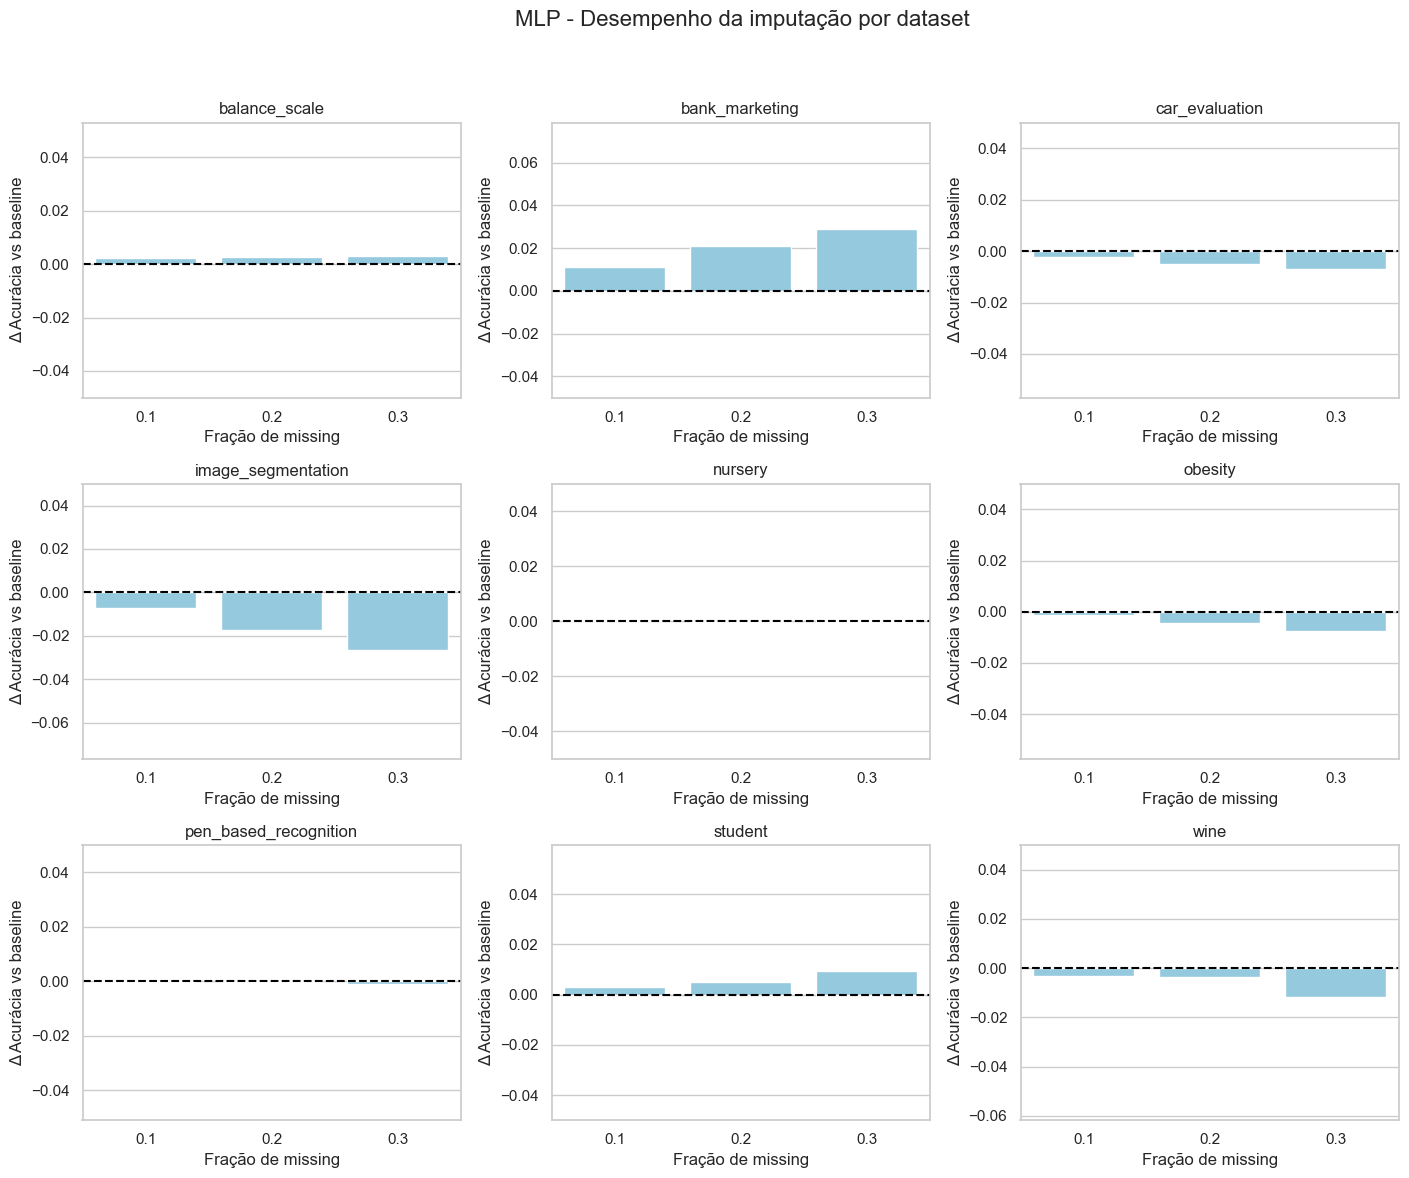

In [78]:
plot_mlp_delta_bars_grid_simple(mlp_long, title="MLP - Desempenho da imputação por dataset")

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_rf_delta_by_variant(rf_long, variant_name):
    # Seleciona apenas a variante desejada
    sub = rf_long[rf_long['variant'] == variant_name].copy()

    # Mantém apenas linhas válidas de delta
    sub = sub[sub['delta_clf'].notna()]
    sub.sort_values(['missing_frac', 'dataset'], inplace=True)

    plt.figure(figsize=(12,6))

    # Plot de barras delta, sem erro
    ax = sns.barplot(
        data=sub,
        x='missing_frac',
        y='delta_clf',
        hue='dataset',
        ci=None,
        palette='Set2'
    )

    # Linha baseline = 0
    ax.axhline(0, color='black', linestyle='--')

    plt.title(f"Random Forest – Variante {variant_name}")
    plt.xlabel("Fração de missing")
    plt.ylabel("Δ Acurácia vs clf_original_mean")

    # Ajuste eixo Y para mostrar negativos e positivos
    y_min = min(sub['delta_clf'].min()-0.05, -0.05)
    y_max = max(sub['delta_clf'].max()+0.05, 0.05)
    plt.ylim(y_min, y_max)

    plt.legend(title="Dataset", bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

C:\Users\felip\AppData\Local\Temp\ipykernel_2908\91586414.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


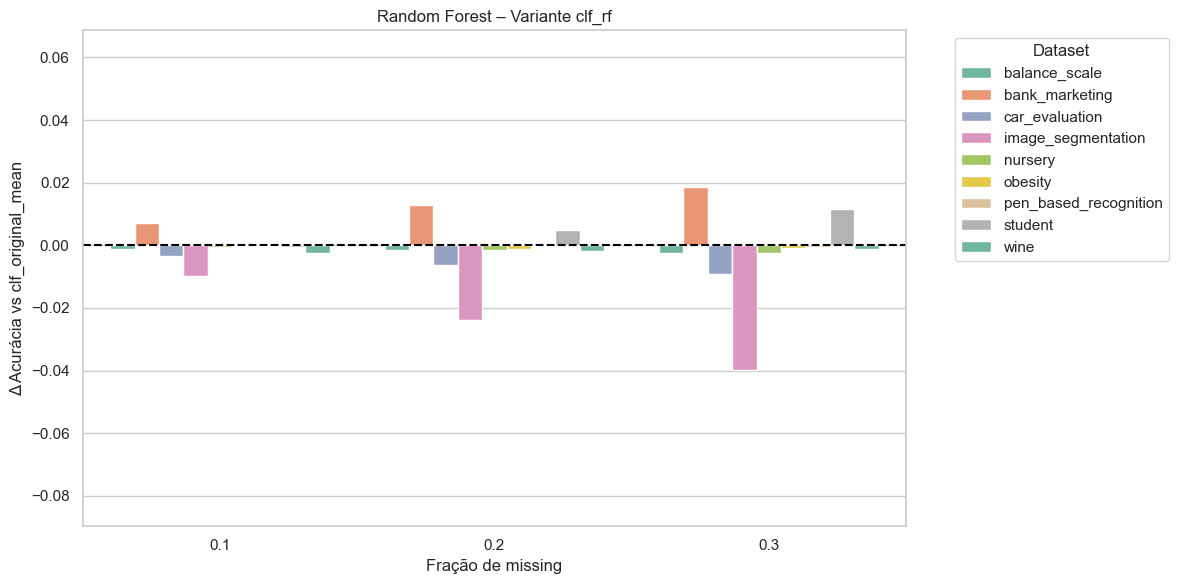

In [80]:
for variant in rf_long['variant'].unique():
    plot_rf_delta_by_variant(rf_long, variant)

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_rf_delta_by_dataset_grid(df, title="Random Forest - Δ Acurácia vs baseline"):
    
    datasets = df['dataset'].unique()
    n = len(datasets)

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4), squeeze=False)
    axes = axes.flatten()

    for i, dataset in enumerate(datasets):
        ax = axes[i]
        sub = df[df['dataset'] == dataset].copy()

        # manter só linhas válidas de delta
        sub = sub[sub['delta_clf'].notna()]
        sub.sort_values(['missing_frac', 'variant'], inplace=True)

        # Plot de barras delta, sem erro
        sns.barplot(
            data=sub,
            x='missing_frac',
            y='delta_clf',
            hue='variant',
            ci=None,
            palette='Set2',
            ax=ax
        )

        # Linha baseline = 0
        ax.axhline(0, color='black', linestyle='--')

        ax.set_title(dataset)

        # Ajuste do eixo Y para mostrar negativos e positivos
        y_min = min(sub['delta_clf'].min()-0.05, -0.05)
        y_max = max(sub['delta_clf'].max()+0.05, 0.05)
        ax.set_ylim(y_min, y_max)

        ax.set_xlabel("Fração de missing")
        ax.set_ylabel("Δ Acurácia vs clf_original_mean")
        ax.legend_.remove()

    # Remover eixos vazios
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # Legenda geral
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title="Variante",
               bbox_to_anchor=(1.02, 0.5), loc='center left')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,0.85,0.95])
    plt.show()

C:\Users\felip\AppData\Local\Temp\ipykernel_2908\2839542605.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\2839542605.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\2839542605.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\2839542605.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\2839542605.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\felip\AppData\Local\Temp\ipykernel_2908\2839542605.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `er

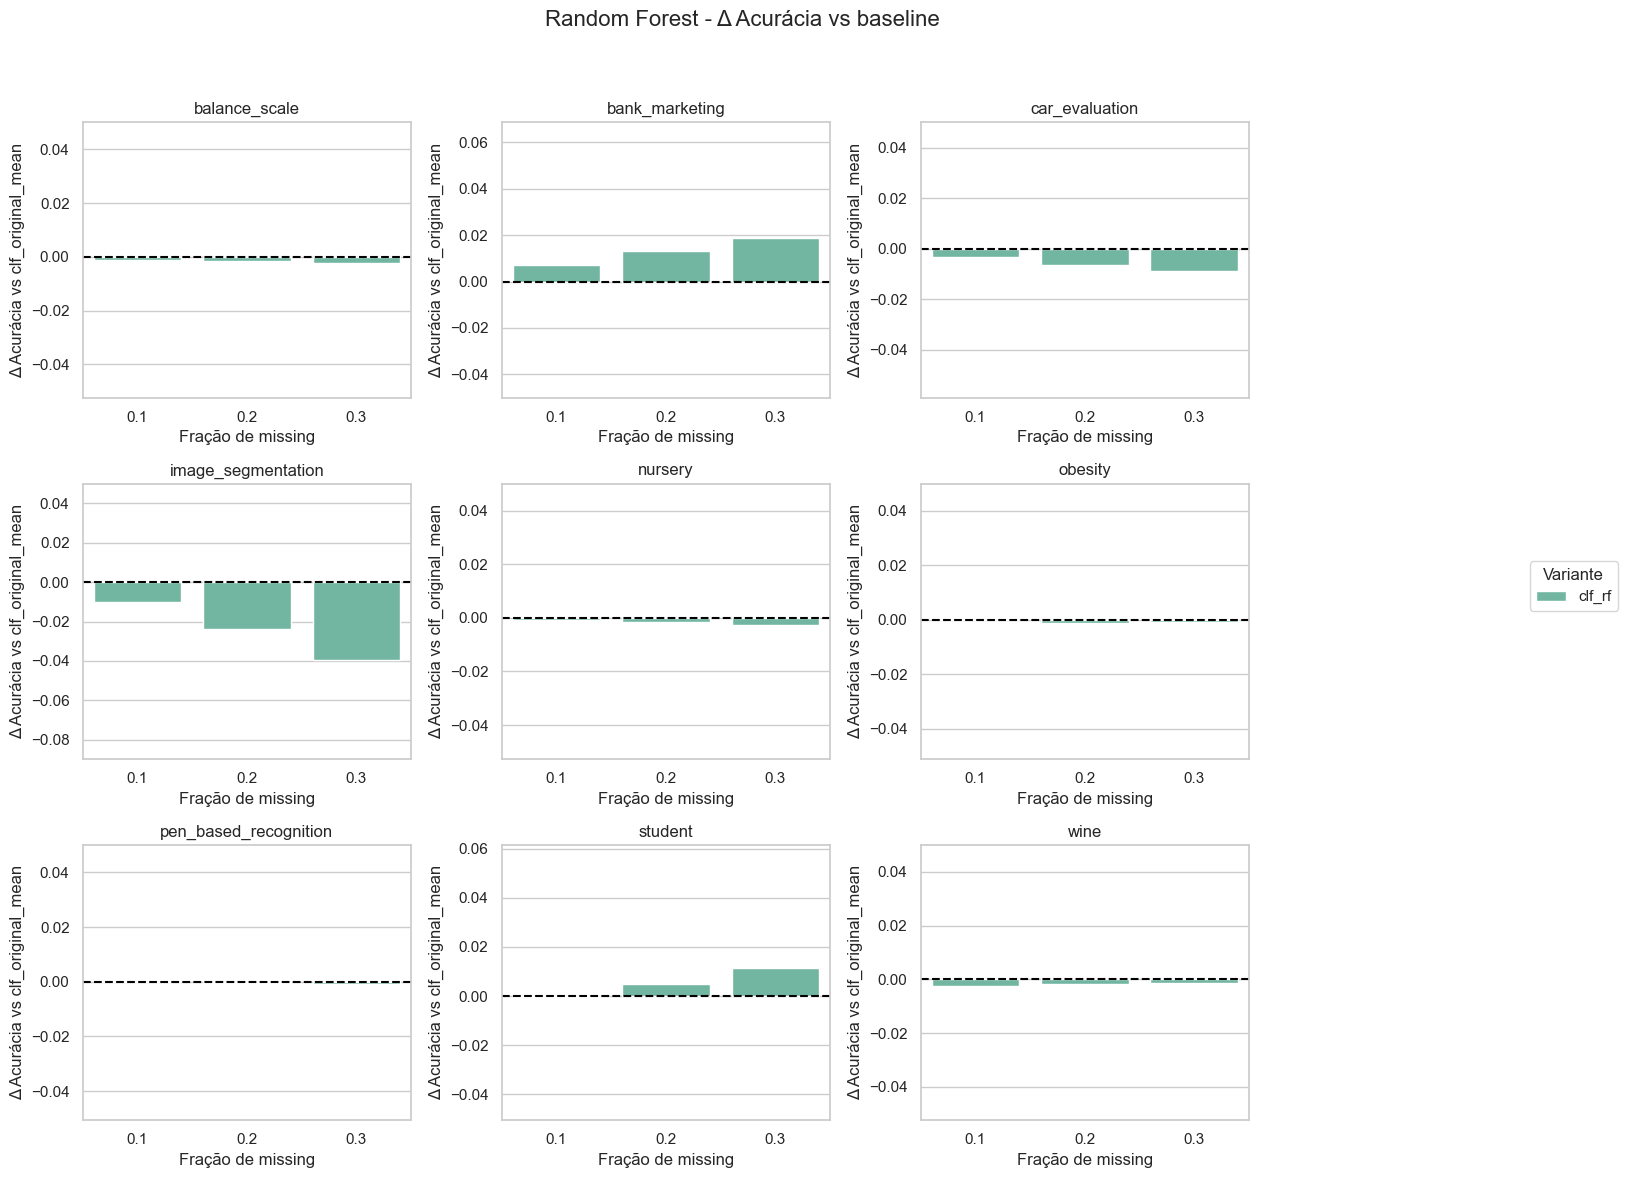

In [82]:
plot_rf_delta_by_dataset_grid(rf_long)

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_all_methods_and_knn_variants(df, title="Δ Acurácia vs baseline – KNN variantes, RF e MLP"):
    
    datasets = df['dataset'].unique()
    n = len(datasets)

    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4), squeeze=False)
    axes = axes.flatten()

    for i, dataset in enumerate(datasets):
        ax = axes[i]
        sub = df[df['dataset'] == dataset].copy()

        # remover baseline
        sub = sub[sub['variant'] != 'clf_original']

        # manter só linhas válidas de delta
        sub = sub[sub['delta_clf'].notna()]

        # ordenar para consistência
        sub.sort_values(['missing_frac', 'method', 'variant'], inplace=True)

        # cores diferentes por método/variante
        palette = {}
        variants_knn = ['clf_simple', 'clf_weighted', 'clf_gower']
        for v in variants_knn:
            palette[v] = 'skyblue'
        palette['MLP'] = 'orange'
        palette['RF'] = 'green'

        # criar coluna combinando method + variant para usar no hue
        sub['method_variant'] = sub.apply(
            lambda row: row['variant'] if 'clf_' in row['variant'] and 'knn' in row['method'].lower() else row['method'],
            axis=1
        )

        sns.barplot(
            data=sub,
            x='missing_frac',
            y='delta_clf',
            hue='method_variant',
            errorbar=None,   # substitui ci=None
            palette=palette,
            ax=ax
        )

        # linha baseline = 0
        ax.axhline(0, color='black', linestyle='--')

        ax.set_title(dataset)

        # eixo Y ajustado para negativos e positivos
        y_min = min(sub['delta_clf'].min()-0.05, -0.05)
        y_max = max(sub['delta_clf'].max()+0.05, 0.05)
        ax.set_ylim(y_min, y_max)

        ax.set_xlabel("Fração de missing")
        ax.set_ylabel("Δ Acurácia vs clf_original_mean")
        ax.legend_.remove()

    # remover eixos vazios
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # legenda geral
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title="Método / Variante",
               bbox_to_anchor=(1.02, 0.5), loc='center left')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0,0,0.85,0.95])
    plt.show()

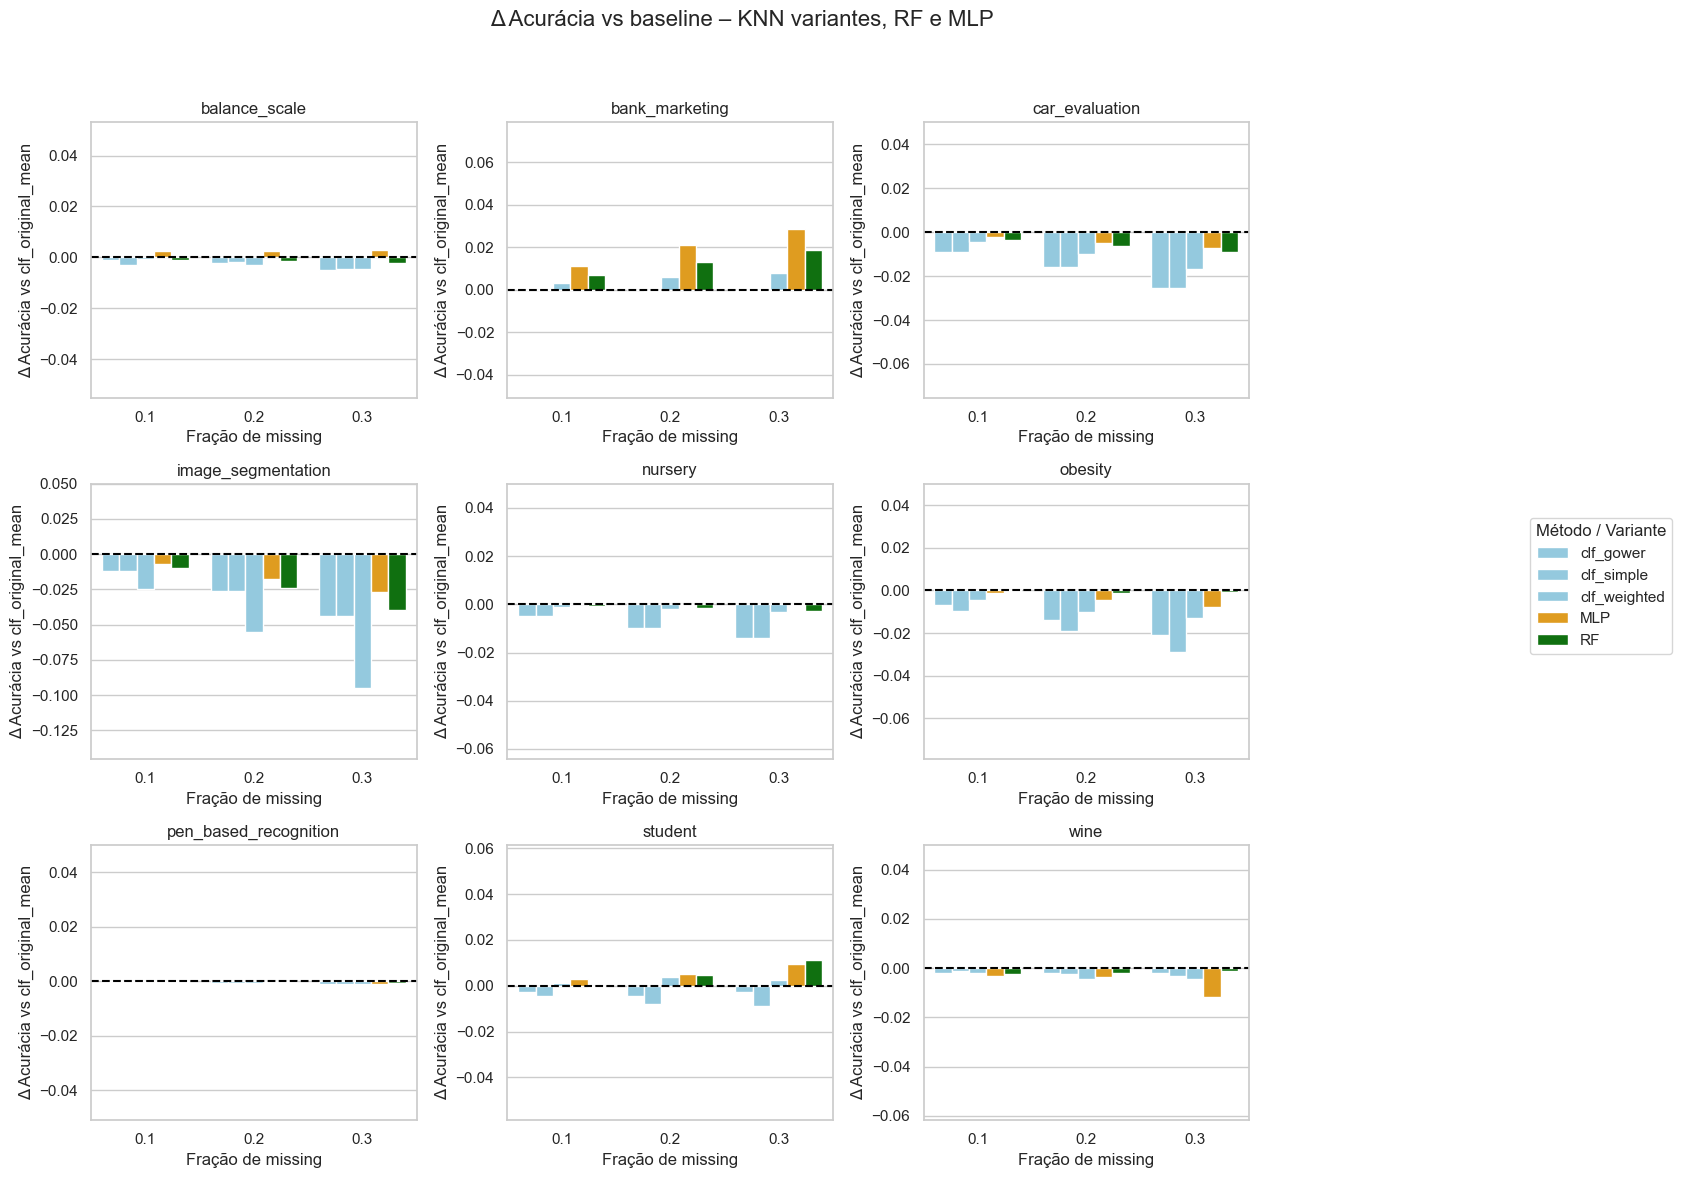

In [92]:
plot_all_methods_and_knn_variants(all_long)
